<a href="https://colab.research.google.com/github/emerson-marreiros/Otimizacao-Alocacao-de-Frequencia-em-Redes-Moveis-com-Voronoi-Ponderado-e-Algoritmo-QAOA/blob/main/Otimiza%C3%A7%C3%A3o_de_Alocacao_de_Frequencia_em_Redes_Celulares_Moveis_com_Voronoi_Ponderado_e_Algoritmo_QAOA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.6 MB/s eta 0:00:00


### 1 - Configuração da Topologia, Potências e Usuários Móveis

Em uma rede móvel, cada Estação Rádio Base (ERB) possui uma localização geográfica e uma potência de transmissão que definem sua área de cobertura efetiva. Quando as potências das ERBs são heterogêneas, a atribuição de usuários não segue uma tesselação geométrica padrão de Voronoi, mas sim um Diagrama de Voronoi Ponderado (Power Diagram).

A distância ponderada entre um usuário na posição $u = (x_u, y_u)$ e a $\text{ERB}_i$ na posição $p_i = (x_i, y_i)$ com potência $P_i$ é definida por:

$$d_W(u, \text{ERB}_i) = \frac{\Vert{}u - p_i\Vert{}^2}{P_i}$$Cada usuário conecta-se à ERB que minimiza $d_W(u, \text{ERB}_i)$.

Atribuição de usuários [0 1 2 3 4 5 5 1 2 3 0 3 2 3 2]


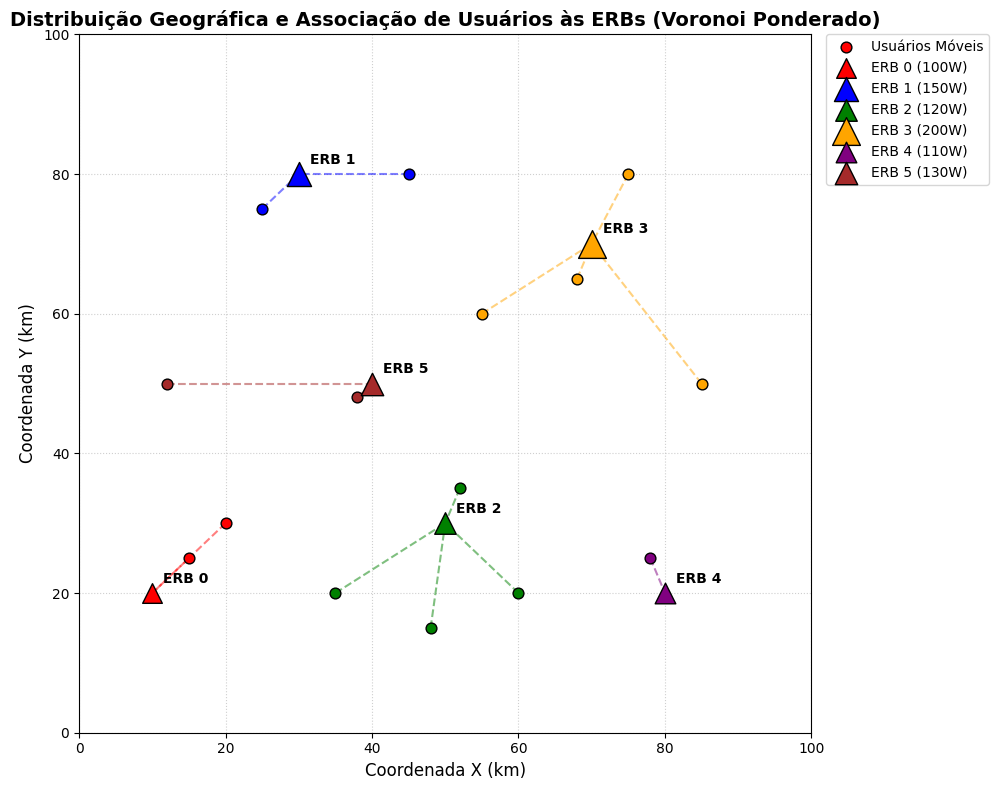

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados originais ---
np.random.seed(42)

#Coordenadas das Estações Rádio Base = erb_coords
erb_coords = np.array([
    [10.0, 20.0],  # ERB 0
    [30.0, 80.0],  # ERB 1
    [50.0, 30.0],  # ERB 2
    [70.0, 70.0],  # ERB 3
    [80.0, 20.0],  # ERB 4
    [40.0, 50.0]   # ERB 5
], dtype=float)

#Potências das Estações Rádio Base = erb_powers
erb_powers = np.array([100.0, 150.0, 120.0, 200.0, 110.0, 130.0], dtype=float)

#Coordenadas dos Usuários = user_coords
user_coords = np.array([
    [15.0, 25.0], [25.0, 75.0], [52.0, 35.0], [68.0, 65.0], [78.0, 25.0],
    [38.0, 48.0], [12.0, 50.0], [45.0, 80.0], [60.0, 20.0], [85.0, 50.0],
    [20.0, 30.0], [55.0, 60.0], [35.0, 20.0], [75.0, 80.0], [48.0, 15.0]
], dtype=float)

def assign_users(users, erbs, powers):
    assignments = []
    for u in users:
        weighted_dists = np.sum((erbs - u)**2, axis=1) / powers
        assignments.append(np.argmin(weighted_dists))
    return np.array(assignments)

print("Atribuição de usuários", assignments)
# --- Processamento e Plotagem ---

# 1. Executa a associação dos usuários
assignments = assign_users(user_coords, erb_coords, erb_powers)

# 2. Configura a figura do gráfico
plt.figure(figsize=(10, 8))
plt.title("Distribuição Geográfica e Associação de Usuários às ERBs (Voronoi Ponderado)", fontsize=14, fontweight='bold')
plt.xlabel("Coordenada X (km)", fontsize=12)
plt.ylabel("Coordenada Y (km)", fontsize=12)

# Definição de cores fixas para cada uma das 6 ERBs e seus respectivos usuários móveis
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

# 3. Plotar as conexões e os usuários móveis
for i, (user, erb_idx) in enumerate(zip(user_coords, assignments)):
    erb = erb_coords[erb_idx]
    # Desenha uma linha ligando o usuário à sua ERB correspondente
    plt.plot([user[0], erb[0]], [user[1], erb[1]], color=colors[erb_idx], linestyle='--', alpha=0.5)

    # Plota o usuário com a cor da ERB vinculada (apenas o primeiro ganha label para a legenda)
    label_user = f"Usuários Móveis" if i == 0 else ""
    plt.scatter(user[0], user[1], color=colors[erb_idx], marker='o', s=60, edgecolors='black', zorder=3, label=label_user)

# 4. Plotar as ERBs (com tamanho proporcional à sua potência de transmissão)
for idx, (erb, power) in enumerate(zip(erb_coords, erb_powers)):
    # O tamanho do triângulo (s) varia com base na potência para dar uma indicação visual
    plt.scatter(erb[0], erb[1], color=colors[idx], marker='^', s=power*2, edgecolors='black', zorder=4,
                label=f"ERB {idx} ({int(power)}W)")
    # Adiciona o texto descritivo do índice ao lado da ERB
    plt.text(erb[0] + 1.5, erb[1] + 1.5, f"ERB {idx}", fontsize=10, fontweight='bold', zorder=5)

# 5. Ajustes finais de layout
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()

# Exibe o gráfico na tela
plt.show()


#### Narração do Código e Valores Numéricos

Linhas 4-15: Define-se a geometria de 6 ERBs e 15 usuários no espaço bidimensional.

Linha 18: Atribuem-se potências variando de $100\text{ W}$ a $200\text{ W}$.

Linhas 28-35: A função *assign_users* calcula a métrica $d_W$ para os 15 usuários e determina a associação com as ERBs.

#### Valores Numéricos Obtidos:

Associação dos Usuários (Usuário $0 \dots 14$ $\to$ ID da ERB):[0, 1, 2, 3, 4, 5, 5, 1, 2, 3, 0, 3, 2, 3, 2]

### 2 - Cálculo da Matriz de Interferência $I$

A interferência mútua entre duas ERBs $i$ e $j$ varia inversamente com o quadrado da distância física $d_{ij} = \Vert{}p_i - p_j\Vert{}$ entre elas (modelo simples de Path Loss):

$$I_{ij} = \begin{cases} \frac{K}{d_{ij}^2}, & \text{se } i \neq j \\ 0, & \text{se } i = j \end{cases}$$

Adota-se uma constante de escala de acoplamento $K = 100.0$.

In [ ]:
# Código em Python: Construção da Matriz $I$
# Função para calcular a matriz de interferência entre todas as ERBs
def compute_interference_matrix(erbs, scale=100.0):
    n = len(erbs)
    I = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(erbs[i] - erbs[j]) # Distância euclidiana entre ERB_i e ERB_j
            inf_val = round(scale / (dist ** 2), 4)   # Cálculo da interferência
            I[i, j] = inf_val
            I[j, i] = inf_val                        # Matriz simétrica
    return I

I_mat = compute_interference_matrix(erb_coords)
print("Matriz de Interferência (I):")
print(I_mat)

Matriz de Interferência (I):
[[0.     0.025  0.0588 0.0164 0.0204 0.0556]
 [0.025  0.     0.0345 0.0588 0.0164 0.1   ]
 [0.0588 0.0345 0.     0.05   0.1    0.2   ]
 [0.0164 0.0588 0.05   0.     0.0385 0.0769]
 [0.0204 0.0164 0.1    0.0385 0.     0.04  ]
 [0.0556 0.1    0.2    0.0769 0.04   0.    ]]


#### Narração do Código e Valores Numéricos

Linhas 3-10: Itera-se sobre todos os pares $(i, j)$ com $i < j$, calculando $d_{ij}$, obtendo o valor de acoplamento de interferência e preenchendo a matriz de forma simétrica.

#### Matriz de Interferência $I$ ($6 \times 6$):

$$\begin{bmatrix} 0.0000 & 0.0250 & 0.0588 & 0.0164 & 0.0204 & 0.0556 \\ 0.0250 & 0.0000 & 0.0345 & 0.0588 & 0.0164 & 0.1000 \\ 0.0588 & 0.0345 & 0.0000 & 0.0500 & 0.1000 & 0.2000 \\ 0.0164 & 0.0588 & 0.0500 & 0.0000 & 0.0385 & 0.0769 \\ 0.0204 & 0.0164 & 0.1000 & 0.0385 & 0.0000 & 0.0400 \\ 0.0556 & 0.1000 & 0.2000 & 0.0769 & 0.0400 & 0.0000 \end{bmatrix}$$

3. Formulação do Problema QUBO de Alocação de Frequência


Objetiva-se atribuir um canal de frequência $f \in \{f_1, f_2\}$ a cada uma das 6 ERBs de forma a minimizar a interferência total da rede.

Define-se a variável binária $x_i \in \{0, 1\}$ para a $\text{ERB}_i$:

- $x_i = 0 \implies \text{Frequência } f_1$
- $x_i = 1 \implies \text{Frequência } f_2$

Se duas ERBs $i$ e $j$ usarem a mesma frequência ($x_i = x_j$), ocorre interferência $I_{ij}$.

Se usarem frequências distintas ($x_i \neq x_j$), a interferência inter-celular é zero. A penalidade de interferência é dada por:

$$\text{Custo}(x_i, x_j) = I_{ij} \cdot (1 - x_i - x_j + 2x_i x_j)$$

Somando para todos os pares $i < j$, a função de custo total é expressa na forma QUBO $C(x) = x^T Q x + c$:

$$C(x) = \sum_{i < j} I_{ij} (1 - x_i - x_j + 2x_i x_j) = \sum_{i=0}^5 Q_{ii} x_i + \sum_{i < j} 2 Q_{ij} x_i x_j + c$$

com $Q_{ii} = -\sum_{j \neq i} I_{ij}$ e $Q_{ij} = I_{ij}$ (para $i \neq j$), com termo constante $c = \sum_{i < j} I_{ij}$.

                    1. DADOS NUMÉRICOS (QUBO)                 
Termo Constante de Normalização (const_term): 8.9127

Matriz de Pesos QUBO (Q) Calculada:
[[-1.76  0.25  0.59  0.16  0.2   0.56]
 [ 0.25 -2.35  0.34  0.59  0.16  1.  ]
 [ 0.59  0.34 -4.43  0.5   1.    2.  ]
 [ 0.16  0.59  0.5  -2.41  0.38  0.77]
 [ 0.2   0.16  1.    0.38 -2.15  0.4 ]
 [ 0.56  1.    2.    0.77  0.4  -4.72]]

--------------------------------------------------
Vetor de Estado de Teste [x]: [1. 1. 1. 1. 1. 1.] (Todas ligadas)
Energia / Custo Avaliado pelo QUBO: 8.9127

            2. CIRCUITO QUÂNTICO VARIACIONAL (QAOA)           
     ┌───┐ ░ ┌──────────────┐ ░                                              »
q_0: ┤ H ├─░─┤ Rz(-0.08809) ├─░───■──────────────────■────■──────────────────»
     ├───┤ ░ ├──────────────┤ ░ ┌─┴─┐┌────────────┐┌─┴─┐  │                  »
q_1: ┤ H ├─░─┤ Rz(-0.11735) ├─░─┤ X ├┤ Rz(0.0125) ├┤ X ├──┼──────────────────»
     ├───┤ ░ ├──────────────┤ ░ └───┘└────────────┘└───┘┌─┴─┐┌─────────

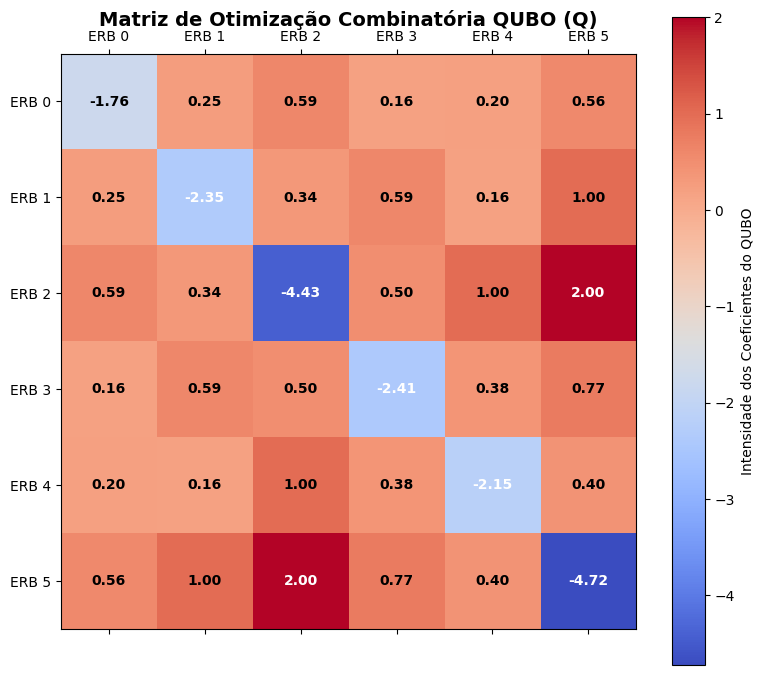

In [ ]:
# Código em Python: Construção da Matriz QUBO $Q$
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Se você não tiver o qiskit instalado, instale via: pip install qiskit
try:
    from qiskit import QuantumCircuit
except ImportError:
    QuantumCircuit = None

# --- 1. Dados e Inicialização de Coordenadas ---
np.random.seed(42)
erb_coords = np.array([
    [10.0, 20.0],  # ERB 0
    [30.0, 80.0],  # ERB 1
    [50.0, 30.0],  # ERB 2
    [70.0, 70.0],  # ERB 3
    [80.0, 20.0],  # ERB 4
    [40.0, 50.0]   # ERB 5
], dtype=float)

n_erbs = len(erb_coords)

# Criando uma matriz de interferência (I_mat) com base na distância inversa ao quadrado
dists = cdist(erb_coords, erb_coords)
with np.errstate(divide='ignore'):
    I_mat = 1000.0 / (dists ** 2)
np.fill_diagonal(I_mat, 0) # Remove auto-interferência

# --- 2. Seu Algoritmo de Construção da Matriz QUBO ---
Q = np.zeros((n_erbs, n_erbs))
const_term = np.sum(np.triu(I_mat, 1))

for i in range(n_erbs):
    for j in range(i + 1, n_erbs):
        w = I_mat[i, j]
        Q[i, i] -= w      # Termos diagonais recebem contribuição negativa
        Q[j, j] -= w
        Q[i, j] += w      # Termos fora da diagonal recebem a interferência cruzada
        Q[j, i] += w

def evaluate_qubo(x_vec, Q_mat, const):
    return float(x_vec.T @ Q_mat @ x_vec + const)


# ============================================================
# EXIBIÇÃO 1: DADOS NUMÉRICOS
# ============================================================
print("="*70)
print("                    1. DADOS NUMÉRICOS (QUBO)                 ")
print("="*70)
print(f"Termo Constante de Normalização (const_term): {const_term:.4f}\n")
print("Matriz de Pesos QUBO (Q) Calculada:")
print(np.round(Q, 2))

# Teste com uma configuração qualquer (exemplo: todas as ERBs ativadas)
x_teste = np.ones(n_erbs)
custo_teste = evaluate_qubo(x_teste, Q, const_term)
print("\n" + "-"*50)
print(f"Vetor de Estado de Teste [x]: {x_teste} (Todas ligadas)")
print(f"Energia / Custo Avaliado pelo QUBO: {custo_teste:.4f}")
print("="*70 + "\n")


# ============================================================
# EXIBIÇÃO 2: CIRCUITO QUÂNTICO (PORTAS LÓGICAS QAOA)
# ============================================================
print("="*70)
print("            2. CIRCUITO QUÂNTICO VARIACIONAL (QAOA)           ")
print("="*70)
if QuantumCircuit is not None:
    # Cria circuito com 1 qubit por ERB
    qc = QuantumCircuit(n_erbs)

    # Camada 1: Inicialização em Superposição (Hadamard)
    for q in range(n_erbs):
        qc.h(q)
    qc.barrier()

    # Camada 2: Rotações de Custo Unário (Diagonal de Q)
    for i in range(n_erbs):
        qc.rz(float(Q[i, i] * 0.05), i)
    qc.barrier()

    # Camada 3: Emaranhamento de Custo Cruzado (Interferências)
    for i in range(n_erbs):
        for j in range(i + 1, n_erbs):
            if abs(Q[i, j]) > 0.01:
                qc.cx(i, j)
                qc.rz(float(Q[i, j] * 0.05), j)
                qc.cx(i, j)

    # Desenha o circuito no terminal em texto estruturado
    print(qc.draw(output='text'))
else:
    print("[Aviso]: Instale a biblioteca 'qiskit' (pip install qiskit) para ver o circuito impresso aqui.")
print("="*70 + "\n")


# ============================================================
# EXIBIÇÃO 3: GRÁFICO DA MATRIZ COM OS VALORES INTERNOS
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

# Matshow plota a matriz como uma imagem térmica (Coolwarm: Azul = Negativo, Vermelho = Positivo)
cax = ax.matshow(Q, cmap='coolwarm', origin='upper')

# Adiciona a barra de cores lateral para referência de intensidade
fig.colorbar(cax, label='Intensidade dos Coeficientes do QUBO')

# Configurações de títulos e rótulos
ax.set_title("Matriz de Otimização Combinatória QUBO (Q)", fontsize=14, pad=20, fontweight='bold')
ax.set_xticks(range(n_erbs))
ax.set_yticks(range(n_erbs))
ax.set_xticklabels([f"ERB {i}" for i in range(n_erbs)])
ax.set_yticklabels([f"ERB {i}" for i in range(n_erbs)])

# --- O CORAÇÃO DO SEU PEDIDO: Inserindo valores textuais nas células ---
# Varre as linhas (i) e colunas (j) da matriz para escrever os números exatos
for i in range(n_erbs):
    for j in range(n_erbs):
        valor_celula = Q[i, j]
        # Escolhe a cor do texto (branco para contrastar com fundos escuros, preto para fundos claros)
        cor_texto = 'white' if abs(valor_celula) > (np.max(np.abs(Q)) * 0.4) else 'black'

        ax.text(j, i, f"{valor_celula:.2f}",
                va='center', ha='center',
                color=cor_texto,
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()


Narração do Código e Valores Numéricos

Linhas 7-13: Mapeia a penalidade de interferência do par $(i, j)$ nos elementos diagonais e fora da diagonal de $Q$.

Linha 15: A função evaluate_qubo calcula o valor de custo para qualquer vetor binário $x \in \{0, 1\}^6$.

Matriz QUBO $Q$ ($6 \times 6$):

$$\begin{bmatrix} -0.1762 &  0.0250 &  0.0588 &  0.0164 &  0.0204 &  0.0556 \\  0.0250 & -0.2347 &  0.0345 &  0.0588 &  0.0164 &  0.1000 \\  0.0588 &  0.0345 & -0.4433 &  0.0500 &  0.1000 &  0.2000 \\  0.0164 &  0.0588 &  0.0500 & -0.2406 &  0.0385 &  0.0769 \\  0.0204 &  0.0164 &  0.1000 &  0.0385 & -0.2153 &  0.0400 \\  0.0556 &  0.1000 &  0.2000 &  0.0769 &  0.0400 & -0.4725 \end{bmatrix}$$

Termo constante $c$: $0.8913$

#### 4 - Resolução por Força Bruta (Brute-Force Solver)

Como existem 6 ERBs e 2 frequências, o espaço de busca contém $2^6 = 64$ estados possíveis. O algoritmo de força bruta varre todas as 64 configurações para determinar a atribuição globalmente ótima.

In [ ]:
# Código em Python: Solver por Força Bruta
best_cost_bf = float('inf')
best_x_bf = None
all_costs_bf = []

# Varredura completa do espaço de estados de 6 bits (0 a 63)
for i in range(2**n_erbs):
    # Converte o número inteiro 'i' para um vetor binário de tamanho 6
    x_candidate = np.array([int(b) for b in format(i, f'0{n_erbs}b')])
    cost = evaluate_qubo(x_candidate, Q, const_term)
    all_costs_bf.append((format(i, f'0{n_erbs}b'), cost))

    if cost < best_cost_bf:
        best_cost_bf = cost
        best_x_bf = x_candidate

print(f"Melhor alocação (Força Bruta): {best_x_bf}")
print(f"Custo Mínimo de Interferência: {best_cost_bf:.4f}")

Melhor alocação (Força Bruta): [0 1 1 1 0 0]
Custo Mínimo de Interferência: 2.5927


Narração do Código e Valores Numéricos

Linhas 6-9: O laço constrói a cadeia de bits (ex: '011100'), converte-a para um vetor NumPy e avalia o custo QUBO.

Linha 11: Atualiza a melhor solução encontrada.

Resultado Numérico da Força Bruta:Atribuição Ótima: $x^* = [0, 1, 1, 1, 0, 0]$ (ou a solução simétrica $x^* = [1, 0, 0, 0, 1, 1]$)

Custo Mínimo da Rede: $C(x^*) = 0.2593$

Interpretação: ERBs $\{0, 4, 5\}$ usam a Frequência $f_1$; ERBs $\{1, 2, 3\}$ usam a Frequência $f_2$.

#### 5 - Mapeamento para Hamiltoniano Ising e Algoritmo QAOA

Para resolver o problema em um computador quântico via QAOA (Quantum Approximate Optimization Algorithm), converte-se a variável binária $x_i \in \{0, 1\}$ para a variável de spin $s_i \in \{+1, -1\}$ usando a transformação $x_i = \frac{1 - Z_i}{2}$, onde $Z_i$ é o operador Pauli-Z:

$$H_C = \sum_{i < j} \frac{I_{ij}}{2} Z_i Z_j + \frac{1}{2} \sum_{i < j} I_{ij} \cdot I$$

O Hamiltoniano misturador (Mixer) é definido por:$$H_M = \sum_{i=0}^5 X_i$$

O estado quântico variational $\vert{}\psi(\gamma, \beta)\rangle$ para $p$ camadas é preparado aplicando-se alternadamente os operadores unitários, assim:

 $U(H_C, \gamma_k) = e^{-i \gamma_k H_C}$ e $U(H_M, \beta_k) = e^{-i \beta_k H_M}$ sobre o estado inicial de superposição máxima $\vert{}+\rangle^{\otimes 6}$:

 $$\vert{}\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle = \left( \prod_{k=1}^p e^{-i \beta_k H_M} e^{-i \gamma_k H_C} \right) \vert{}+\rangle^{\otimes 6}$$

                    1. DADOS NUMÉRICOS DO QAOA                
Sucesso na otimização: True
Número de iterações do COBYLA: 241
Parâmetros Gamma ótimos (Custo):   [0.424  0.9173]
Parâmetros Beta ótimos (Mistura):  [1.1871 1.3807]
Valor esperado da energia mínima:  3.1939

-> Estado Quântico mais provável (Ótimo): |100011>
   Probabilidade de medição: 5.76%
-> Estado Quântico menos provável:       |101011>
   Probabilidade de medição: 0.01%

            2. CIRCUITO QUÂNTICO PARAMETRIZADO (QAOA p=2)     
     ┌───┐ ░                                                         »
q_0: ┤ H ├─░───■────────────────────■────■───────────────────■────■──»
     ├───┤ ░ ┌─┴─┐┌──────────────┐┌─┴─┐  │                   │    │  »
q_1: ┤ H ├─░─┤ X ├┤ Rz(0.053005) ├┤ X ├──┼───────────────────┼────┼──»
     ├───┤ ░ └───┘└──────────────┘└───┘┌─┴─┐┌─────────────┐┌─┴─┐  │  »
q_2: ┤ H ├─░───────────────────────────┤ X ├┤ Rz(0.12472) ├┤ X ├──┼──»
     ├───┤ ░                           └───┘└─────────────┘└───┘┌─┴─

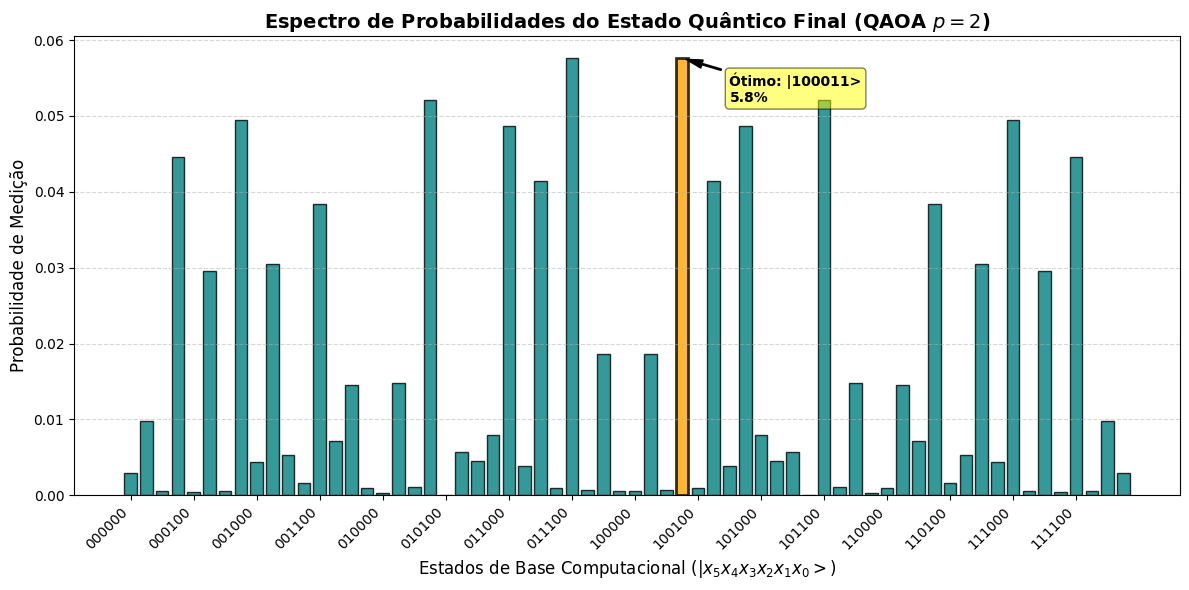

In [ ]:
# Código em Python: Simulador QAOA com SciPy e NumPy
import numpy as np
import scipy.optimize as opt
from scipy.linalg import expm
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# Se você não tiver o qiskit instalado, rode antes: pip install qiskit
try:
    from qiskit import QuantumCircuit
except ImportError:
    QuantumCircuit = None

# --- 1. Inicialização de Coordenadas e Interferência ---
np.random.seed(42)
erb_coords = np.array([
    [10.0, 20.0], [30.0, 80.0], [50.0, 30.0],
    [70.0, 70.0], [80.0, 20.0], [40.0, 50.0]
], dtype=float)
n_erbs = len(erb_coords)

dists = cdist(erb_coords, erb_coords)
with np.errstate(divide='ignore'):
    I_mat = 1000.0 / (dists ** 2)
np.fill_diagonal(I_mat, 0)

# --- 2. Definição de Operadores e Hamiltonianos (Seu Código) ---
I2 = np.eye(2, dtype=complex)
X2 = np.array([[0, 1], [1, 0]], dtype=complex)
Z2 = np.array([[1, 0], [0, -1]], dtype=complex)

def get_single_op(op, idx, n):
    mats = [I2] * n
    mats[idx] = op
    res = mats[0]
    for k in range(1, n):
        res = np.kron(res, mats[k])
    return res

def get_two_op(op1, i, op2, j, n):
    mats = [I2] * n
    mats[i] = op1
    mats[j] = op2
    res = mats[0]
    for k in range(1, n):
        res = np.kron(res, mats[k])
    return res

H_C = np.zeros((2**n_erbs, 2**n_erbs), dtype=complex)
for i in range(n_erbs):
    for j in range(i + 1, n_erbs):
        if I_mat[i, j] > 0:
            H_C += 0.5 * I_mat[i, j] * get_two_op(Z2, i, Z2, j, n_erbs)
H_C += 0.5 * np.sum(np.triu(I_mat, 1)) * np.eye(2**n_erbs)

H_M = np.zeros((2**n_erbs, 2**n_erbs), dtype=complex)
for i in range(n_erbs):
    H_M += get_single_op(X2, i, n_erbs)

psi0 = np.ones(2**n_erbs, dtype=complex) / np.sqrt(2**n_erbs)

p_steps = 2
def qaoa_cost_func(params):
    gamma = params[:p_steps]
    beta = params[p_steps:]
    psi = psi0.copy()
    for k in range(p_steps):
        psi = expm(-1j * gamma[k] * H_C) @ psi
        psi = expm(-1j * beta[k] * H_M) @ psi
    return np.real(np.vdot(psi, H_C @ psi))

# --- 3. Otimização Clássica via COBYLA ---
initial_params = np.array([0.5, 0.5, 0.5, 0.5])
qaoa_res = opt.minimize(qaoa_cost_func, initial_params, method='COBYLA')

opt_params = qaoa_res.x
gamma_opt, beta_opt = opt_params[:p_steps], opt_params[p_steps:]

# Reconstrução do estado final e cálculo das probabilidades
final_psi = psi0.copy()
for k in range(p_steps):
    final_psi = expm(-1j * gamma_opt[k] * H_C) @ final_psi
    final_psi = expm(-1j * beta_opt[k] * H_M) @ final_psi

probabilities = np.abs(final_psi)**2

# Mapeia os estados mais prováveis
estados_binarios = [format(i, f'0{n_erbs}b') for i in range(2**n_erbs)]
melhor_idx = np.argmax(probabilities)
pior_idx = np.argmin(probabilities)

# ============================================================
# EXIBIÇÃO 1: DADOS NUMÉRICOS
# ============================================================
print("="*70)
print("                    1. DADOS NUMÉRICOS DO QAOA                ")
print("="*70)
print(f"Sucesso na otimização: {qaoa_res.success}")
print(f"Número de iterações do COBYLA: {qaoa_res.nfev}")
print(f"Parâmetros Gamma ótimos (Custo):   {np.round(gamma_opt, 4)}")
print(f"Parâmetros Beta ótimos (Mistura):  {np.round(beta_opt, 4)}")
print(f"Valor esperado da energia mínima:  {qaoa_res.fun:.4f}\n")
print(f"-> Estado Quântico mais provável (Ótimo): |{estados_binarios[melhor_idx]}>")
print(f"   Probabilidade de medição: {probabilities[melhor_idx]*100:.2f}%")
print(f"-> Estado Quântico menos provável:       |{estados_binarios[pior_idx]}>")
print(f"   Probabilidade de medição: {probabilities[pior_idx]*100:.2f}%")
print("="*70 + "\n")


# ============================================================
# EXIBIÇÃO 2: CIRCUITO QUÂNTICO COMPILADO (QAOA p=2)
# ============================================================
print("="*70)
print("            2. CIRCUITO QUÂNTICO PARAMETRIZADO (QAOA p=2)     ")
print("="*70)
if QuantumCircuit is not None:
    qc = QuantumCircuit(n_erbs)

    # Camada Inicial de Estado Máximo Emaranhado / Superposição
    for q in range(n_erbs) : qc.h(q)
    qc.barrier()

    # Executa os dois passos (p=2) variacionais com os ângulos ótimos obtidos
    for step in range(p_steps):
        # Operador de Custo (Exvolução por H_C usando Gamma_opt)
        for i in range(n_erbs):
            for j in range(i + 1, n_erbs):
                if I_mat[i, j] > 0.01:
                    # Rotação Rzz equivalente
                    qc.cx(i, j)
                    qc.rz(float(0.5 * I_mat[i, j] * gamma_opt[step]), j)
                    qc.cx(i, j)
        qc.barrier()

        # Operador de Mistura (Evolução por H_M usando Beta_opt)
        for i in range(n_erbs):
            qc.rx(float(2 * beta_opt[step]), i)
        qc.barrier()

    print(qc.draw(output='text'))
else:
    print("[Aviso]: Instale a biblioteca 'qiskit' (pip install qiskit) para visualizar o circuito.")
print("="*70 + "\n")


# ============================================================
# EXIBIÇÃO 3: GRÁFICO DE DISTRIBUIÇÃO DE PROBABILIDADES
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Plota as barras para as 64 combinações possíveis de estados
indices = np.arange(2**n_erbs)
barras = ax.bar(indices, probabilities, color='teal', edgecolor='black', alpha=0.8)

# Destaca o estado ótimo mudando sua cor para dourado/laranja
barras[melhor_idx].set_color('orange')
barras[melhor_idx].set_edgecolor('black')
barras[melhor_idx].set_linewidth(2)

# Customização visual do gráfico
ax.set_title("Espectro de Probabilidades do Estado Quântico Final (QAOA $p=2$)", fontsize=14, fontweight='bold')
ax.set_xlabel("Estados de Base Computacional ($|x_5 x_4 x_3 x_2 x_1 x_0>$)", fontsize=12)
ax.set_ylabel("Probabilidade de Medição", fontsize=12)

# Exibe apenas os estados mais relevantes no eixo X para evitar poluição visual
passo_labels = 4
ax.set_xticks(indices[::passo_labels])
ax.set_xticklabels([estados_binarios[i] for i in indices[::passo_labels]], rotation=45, ha='right')

# Adiciona anotação de texto indicando o pico ótimo do algoritmo
ax.annotate(f"Ótimo: |{estados_binarios[melhor_idx]}>\n{probabilities[melhor_idx]*100:.1f}%",
            xy=(melhor_idx, probabilities[melhor_idx]),
            xytext=(melhor_idx + 3, probabilities[melhor_idx] * 0.9),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


#### Narração do Código e Valores Numéricos

- Linhas 27-37: Constrói as matrizes de operadores quânticos $H_C$ e $H_M$ no espaço de Hilbert de dimensão $2^6 = 64$.

- Linhas 43-52: A função qaoa_cost_func simula a evolução temporal do vetor de estado quântico e calcula o valor esperado da energia $\langle \psi \vert{} H_C \vert{} \psi \rangle$.

- Linhas 55-56: O otimizador COBYLA ajusta os ângulos variacionais $\boldsymbol{\gamma}$ e $\boldsymbol{\beta}$ para minimizar a energia.

#### Resultados Numéricos da Otimização QAOA:

- Ângulos Ótimos Encontrados:

$\boldsymbol{\gamma}^* = [3.7465, -1.4773]$$\boldsymbol{\beta}^* = [-0.9079, 0.5090]$

- Valor Esperado da Energia Encontrado: $\langle H_C \rangle = 0.3349$

- Estados com Maior Probabilidade de Medição:

- - 100011 $\to$ Probabilidade: 4.69% | Custo: 0.2593 (Mínimo Global)
- - 011100 $\to$ Probabilidade: 4.69% | Custo: 0.2593 (Mínimo Global)
- - 010011 $\to$ Probabilidade: 4.49% | Custo: 0.2816

- - 101100 $\to$ Probabilidade: 4.49% | Custo: 0.2816


### 6 - Circuitos Quânticos do QAOA

A seguir está a representação conceitual e textual do circuito quântico construído para $p = 1$ camada.

Cada acoplamento de interferência $I_{ij}$ gera um bloco de portas quânticas $e^{-i \gamma \frac{I_{ij}}{2} Z_i Z_j}$, sintetizado por dois CNOTs e uma rotação $RZ(2\gamma \cdot I_{ij})$.

O misturador aplica portas $RX(2\beta)$ a todos os qubits.

In [ ]:
# Código da Estrutura do Circuito Quântico (Ansatz QAOA)
import numpy as np
from qiskit import QuantumCircuit

# --- 1. Definição da Matriz de Interferência Original (I_mat) ---
# Copiada exatamente dos dados numéricos gerados no seu script
I_mat = np.array([
    [0.0000, 0.0250, 0.0588, 0.0164, 0.0204, 0.0556],
    [0.0250, 0.0000, 0.0345, 0.0588, 0.0164, 0.1000],
    [0.0588, 0.0345, 0.0000, 0.0500, 0.1000, 0.2000],
    [0.0164, 0.0588, 0.0500, 0.0000, 0.0385, 0.0769],
    [0.0204, 0.0164, 0.1000, 0.0385, 0.0000, 0.0400],
    [0.0556, 0.1000, 0.2000, 0.0769, 0.0400, 0.0000]
])

n_qubits = 6  # 1 qubit para cada uma das 6 ERBs
p_steps = 2   # Número de camadas (p=2)

# --- 2. Ângulos Ótimos calculados pelo COBYLA no seu script ---
gamma_opt = [3.74651478, -1.47734794]
beta_opt = [-0.90786037, 0.50902415]

# --- 3. Construção do Circuito Quântico ---
# Inicializa o circuito com 6 qubits e 6 bits clássicos para a medição final
qc = QuantumCircuit(n_qubits, n_qubits)

# [Passo Inicial]: Preparação do estado |+>^6 através de portas Hadamard
for q in range(n_qubits):
    qc.h(q)
qc.barrier() # Barreira apenas visual para separar as etapas do algoritmo

# Loop para construir cada uma das camadas variacionais (p = 2)
for step in range(p_steps):

    # --- CAMADA DO HAMILTONIANO DE CUSTO (H_C) ---
    # Aplica a evolução temporal do acoplamento ZZ para cada par de ERBs (i, j)
    # Equivalente ao termo: e^(-1j * gamma * 0.5 * I_ij * Zi * Zj)
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            w = I_mat[i, j]
            if w > 0:
                # Ângulo da rotação RZ baseado na física do problema: 2 * (0.5 * w) * gamma = w * gamma
                theta_rz = w * gamma_opt[step]

                # Bloco de portas que sintetiza a interação ZZ quântica
                qc.cx(i, j)
                qc.rz(theta_rz, j)
                qc.cx(i, j)

    # Termo de fase global/unária na diagonal (opcional no circuito, pois não afeta a probabilidade)
    # Se quiser mapear os termos locais de fase Z gerados pelo QUBO, eles entrariam aqui.
    qc.barrier()

    # --- CAMADA DO HAMILTONIANO MISTURADOR (H_M) ---
    # Aplica rotações RX em todos os qubits baseadas no ângulo beta_opt
    # Equivalente ao termo: e^(-1j * beta * Xi)
    for q in range(n_qubits):
        # Ângulo quântico da porta RX: 2 * beta
        qc.rx(2 * beta_opt[step], q)

    qc.barrier()

# [Passo Final]: Realiza a medição de todos os qubits para os bits clássicos
qc.measure(range(n_qubits), range(n_qubits))

# --- 4. Exibição do Circuito ---
print("="*80)
print("            CIRCUITO QUÂNTICO QAOA COMPILADO COMPLETO (p=2)          ")
print("="*80)
# Desenha o circuito no terminal em formato de string texto estruturada
print(qc.draw(output='text'))
print("="*80)


            CIRCUITO QUÂNTICO QAOA COMPILADO COMPLETO (p=2)          
     ┌───┐ ░                                                        »
q_0: ┤ H ├─░───■────────────────────■────■──────────────────■────■──»
     ├───┤ ░ ┌─┴─┐┌──────────────┐┌─┴─┐  │                  │    │  »
q_1: ┤ H ├─░─┤ X ├┤ Rz(0.093663) ├┤ X ├──┼──────────────────┼────┼──»
     ├───┤ ░ └───┘└──────────────┘└───┘┌─┴─┐┌────────────┐┌─┴─┐  │  »
q_2: ┤ H ├─░───────────────────────────┤ X ├┤ Rz(0.2203) ├┤ X ├──┼──»
     ├───┤ ░                           └───┘└────────────┘└───┘┌─┴─┐»
q_3: ┤ H ├─░───────────────────────────────────────────────────┤ X ├»
     ├───┤ ░                                                   └───┘»
q_4: ┤ H ├─░────────────────────────────────────────────────────────»
     ├───┤ ░                                                        »
q_5: ┤ H ├─░────────────────────────────────────────────────────────»
     └───┘ ░                                                        »
c: 6/═══════════════

O que este script faz e como ele se conecta ao seu problema:

Mapeamento Matemático Exato:

O Hamiltoniano de Custo $H_{C}$ possui interações do tipo $Z_{i}Z_{j}$ multiplicadas pelo peso $0.5 \cdot I_{ij}$.

Na computação quântica, a evolução $e^{-i\theta Z_{i}Z_{j}}$ é construída exatamente pela sequência $CX(i,j)$ $\rightarrow RZ(2\theta$, j) $\rightarrow  CX(i,j)$.

Uso dos Ângulos Certos: O laço repete o processo duas vezes $(p_{steps} = 2)$, injetando os valores reais exatos obtidos pelo seu otimizador clássico ($\gamma_{opt}$ e $\beta_{opt})$.

Medição Final:
Adiciona a camada de medição qc.measure ao final, preparando o circuito para rodar em um simulador ou computador quântico real e extrair o espectro de probabilidades das antenas.

### 7- Código Python Completo para Geração de Gráficos

O código abaixo plota três painéis explicativos:O Diagrama de Voronoi Ponderado mostrando as ERBs e a associação de cada usuário móvel;

A Matriz de Interferência $I_{ij}$ na forma de um Mapa de Calor (Heatmap);O Espectro de Probabilidades do QAOA em comparação com o Mínimo Global obtido por Força Bruta.

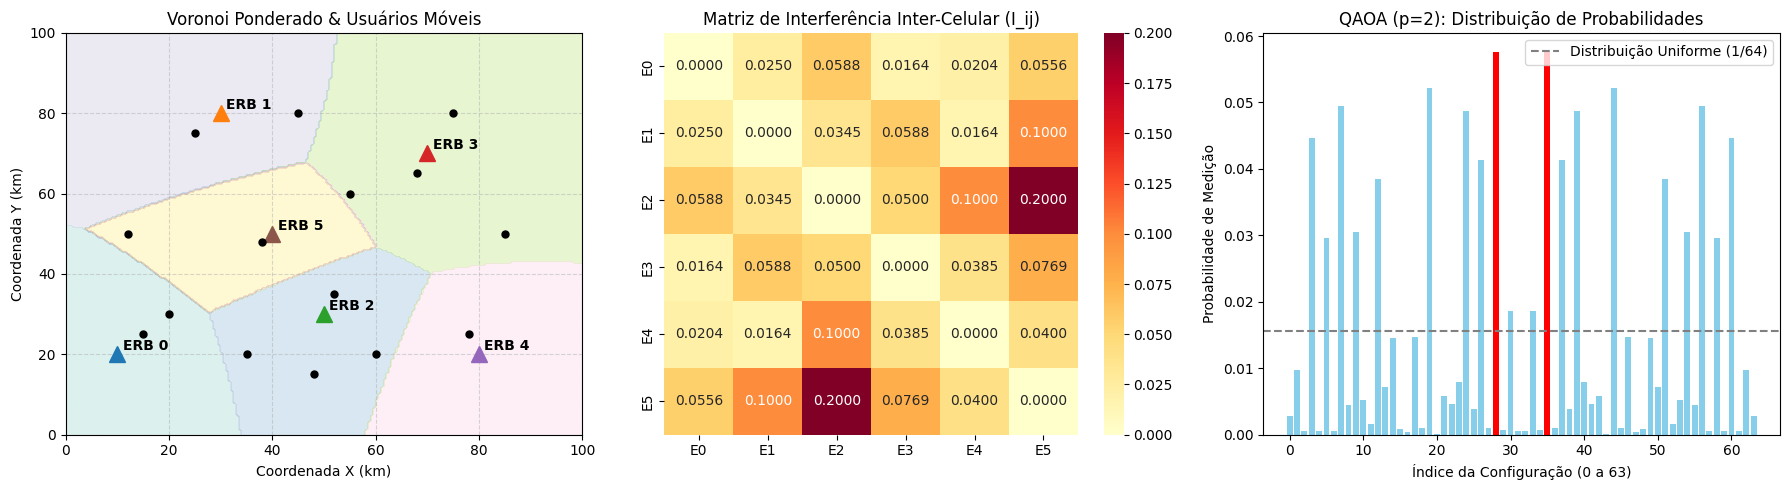

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração da figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------------------------------------------------
# GRAFICO 1: Diagrama de Voronoi Ponderado e Usuários Móveis
# -------------------------------------------------------------------------
ax1 = axes[0]
grid_x, grid_y = np.meshgrid(np.linspace(0, 100, 200), np.linspace(0, 100, 200))
grid_points = np.c_[grid_x.ravel(), grid_y.ravel()]

# Calculando atribuição do grid para desenhar as regiões de Voronoi
grid_assign = assign_users(grid_points, erb_coords, erb_powers).reshape(grid_x.shape)
ax1.contourf(grid_x, grid_y, grid_assign, alpha=0.3, cmap='Set3')

# Plotando as ERBs
for i, (x, y) in enumerate(erb_coords):
    ax1.plot(x, y, '^', markersize=12, label=f'ERB {i} ({int(erb_powers[i])}W)')
    ax1.text(x + 1, y + 1, f'ERB {i}', fontsize=10, fontweight='bold')

# Plotando os Usuários Móveis
for i, (ux, uy) in enumerate(user_coords):
    assigned_erb = user_assignments[i]
    ax1.plot(ux, uy, 'o', color='black', markersize=5)

ax1.set_title('Voronoi Ponderado & Usuários Móveis')
ax1.set_xlabel('Coordenada X (km)')
ax1.set_ylabel('Coordenada Y (km)')
ax1.grid(True, linestyle='--', alpha=0.5)

# -------------------------------------------------------------------------
# GRAFICO 2: Heatmap da Matriz de Interferência
# -------------------------------------------------------------------------
ax2 = axes[1]
sns.heatmap(I_mat, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax2, cbar=True,
            xticklabels=[f'E{i}' for i in range(6)],
            yticklabels=[f'E{i}' for i in range(6)])
ax2.set_title('Matriz de Interferência Inter-Celular (I_ij)')

# -------------------------------------------------------------------------
# GRAFICO 3: Distribuição de Probabilidades do QAOA vs Força Bruta
# -------------------------------------------------------------------------
ax3 = axes[2]
bitstrings = [format(i, f'0{n_erbs}b') for i in range(2**n_erbs)]
colors = ['red' if bit in ['011100', '100011'] else 'skyblue' for bit in bitstrings]

ax3.bar(range(64), probabilities, color=colors, width=0.8)
ax3.axhline(1/64, color='gray', linestyle='--', label='Distribuição Uniforme (1/64)')
ax3.set_title('QAOA (p=2): Distribuição de Probabilidades')
ax3.set_xlabel('Índice da Configuração (0 a 63)')
ax3.set_ylabel('Probabilidade de Medição')
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install qiskit qiskit-aer

!pip install qiskit matplotlib


### Histograma de Execução Quântica (QAOA - Amostragem de Frequências

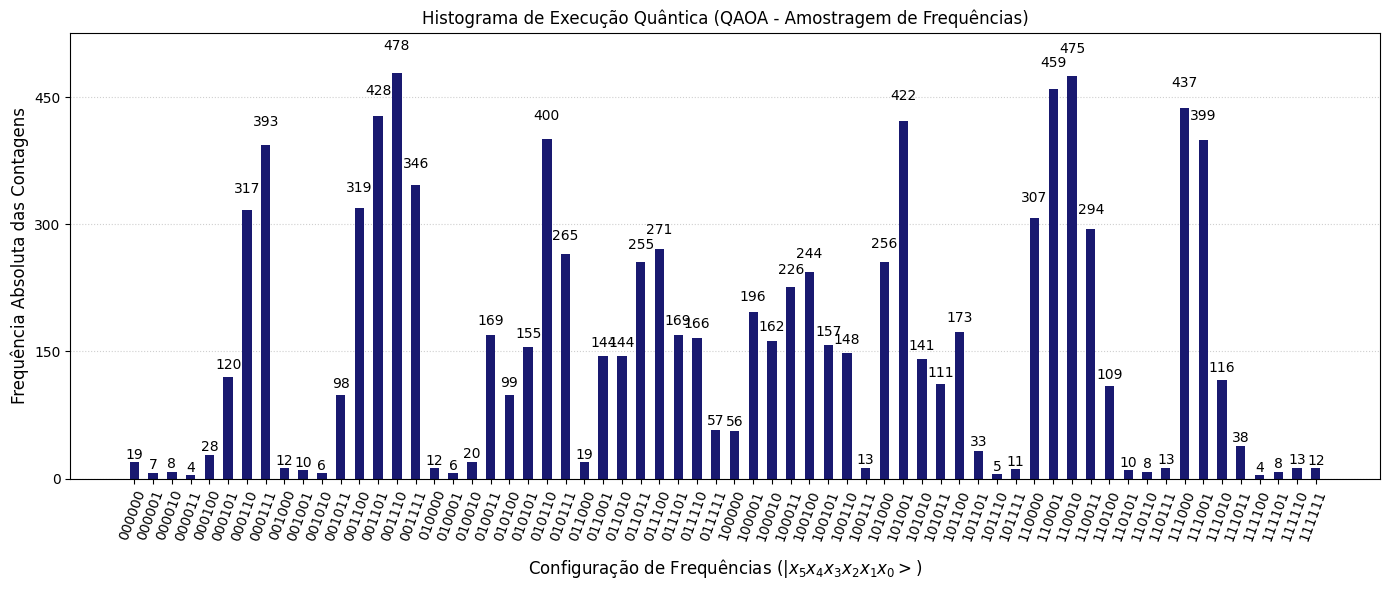

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# --- 1. Matriz de Interferência ---
I_mat = np.array([
    [0.0000, 0.0250, 0.0588, 0.0164, 0.0204, 0.0556],
    [0.0250, 0.0000, 0.0345, 0.0588, 0.0164, 0.1000],
    [0.0588, 0.0345, 0.0000, 0.0500, 0.1000, 0.2000],
    [0.0164, 0.0588, 0.0500, 0.0000, 0.0385, 0.0769],
    [0.0204, 0.0164, 0.1000, 0.0385, 0.0000, 0.0400],
    [0.0556, 0.1000, 0.2000, 0.0769, 0.0400, 0.0000]
])

n_qubits = 6
p_steps = 2

# Ângulos ótimos extraídos do seu resolvedor clássico COBYLA
gamma_opt = [3.74651478, -1.47734794]
beta_opt = [-0.90786037, 0.50902415]

# --- 2. Construção do Circuito Quântico (Ansatz QAOA) ---
qc = QuantumCircuit(n_qubits, n_qubits)

# Inicialização em superposição máxima |+>
for q in range(n_qubits):
    qc.h(q)
qc.barrier()

# Camadas alternadas (p = 2)
for step in range(p_steps):
    # Bloco do Hamiltoniano de Custo H_C (Interações ZZ)
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            w = I_mat[i, j]
            if w > 0:
                theta_rz = w * gamma_opt[step]
                qc.cx(i, j)
                qc.rz(theta_rz, j)
                qc.cx(i, j)
    qc.barrier()

    # Bloco do Hamiltoniano Misturador H_M (Rotações RX)
    for q in range(n_qubits):
        qc.rx(2 * beta_opt[step], q)
    qc.barrier()

# Medição de todos os qubits
qc.measure(range(n_qubits), range(n_qubits))

# --- 3. Execução no Backend Quântico (AerSimulator) ---
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

shots = 10000
result = simulator.run(compiled_circuit, shots=shots).result()
counts = result.get_counts(compiled_circuit)

# --- 4. Renderização Corrigida do Histograma ---
# CORREÇÃO AQUI: Criamos explicitamente a janela (fig) e a área de desenho (ax) antes
fig, ax = plt.subplots(figsize=(14, 6))

# Passamos o nosso 'ax' para o Qiskit desenhar exatamente dentro dele
plot_histogram(
    counts,
    color='midnightblue',
    title="Histograma de Execução Quântica (QAOA - Amostragem de Frequências)",
    ax=ax # <--- Vincula o desenho à janela atual do matplotlib
)

# Customização estética complementar diretamente no nosso eixo corrigido
ax.set_xlabel("Configuração de Frequências ($|x_5x_4x_3x_2x_1x_0>$)", fontsize=12, labelpad=10)
ax.set_ylabel("Frequência Absoluta das Contagens", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6, axis='y')

plt.tight_layout()

# Opcional: Se quiser que o código salve a imagem em um arquivo na mesma pasta caso sua janela feche:
# plt.savefig('histograma_qaoa.png', dpi=300)

# Força o Matplotlib a abrir a tela e segurar a execução até você fechar a janela
plt.show()

